In [2]:
import os
from pathlib import Path
import pandas as pd

In [3]:
temp_df = pd.read_csv("../dati/streaming_row/051224/dati_mqtt_realtime.csv")
temp_df.columns

Index(['Topic', 'Valore', 'Timestamp'], dtype='object')

In [4]:
temp_df.head()

,Topic,Valore,Timestamp
0,bonfi/gb1_p4_temp,52.500000,Thu Oct 24 11:18:21 2024
1,bonfi/gb1_p4_acc_rms,0.338097,Thu Oct 24 11:18:21 2024
2,bonfi/gb1_p4_acc_kurt,0.008381,Thu Oct 24 11:18:21 2024
3,bonfi/gb1_p4_acc_cfa,3.399808,Thu Oct 24 11:18:21 2024
4,bonfi/gb1_p4_acc_skew,-0.083490,Thu Oct 24 11:18:21 2024


In [5]:
import os
from pathlib import Path
import pandas as pd

base_path = Path(r"C:\Users\OrsoPeruzzi\PycharmProjects\safe\dati\streaming_row")
real_time_files = list(base_path.glob("*/dati_mqtt_realtime.csv"))

df_list = []
for csv_file in real_time_files:
    # 1) Prima lettura "normale", sperando che ci sia l'intestazione
    temp_df = pd.read_csv(csv_file)

    # 2) Controllo se esiste la colonna Timestamp
    if 'Timestamp' not in temp_df.columns:
        # Se non esiste, probabilmente il file non ha header.
        # Riproviamo a leggerlo indicando noi i nomi delle colonne.
        print(f"Il file {csv_file} non ha header. Riprovo con header=None ...")
        temp_df = pd.read_csv(
            csv_file,
            header=None,                       # disattiva la lettura dell’header
            names=['Topic', 'Valore', 'Timestamp']  # assegna i nomi giusti
        )

    # Adesso dovremmo avere almeno 3 colonne.
    # Se ancora non c’è 'Timestamp', allora proprio non possiamo usarlo come time series!
    if 'Timestamp' not in temp_df.columns:
        print(f"Il file {csv_file} non contiene la colonna 'Timestamp'. Salto il file.")
        continue

    # Converte Timestamp in datetime
    temp_df['Timestamp'] = pd.to_datetime(
        temp_df['Timestamp'],
        format="%a %b %d %H:%M:%S %Y",
        errors='coerce'
    )

    # Rimuove righe con Timestamp = NaT
    temp_df.dropna(subset=['Timestamp'], inplace=True)

    # Aggiunge alla lista solo se non vuoto
    if not temp_df.empty:
        df_list.append(temp_df)

# Unione dei vari DataFrame letti correttamente
df = pd.concat(df_list, ignore_index=True)

# ... (dopo aver unito i DataFrame e prima del pivot) ...
df.drop_duplicates(subset=['Timestamp', 'Topic'], keep='first', inplace=True)

df_ts = df.pivot(index='Timestamp', columns='Topic', values='Valore')


# Ordina cronologicamente l'indice
df_ts.sort_index(inplace=True)

ValueError: No objects to concatenate

In [2]:
df_ts.head()

Topic,bonfi/gb1_p3_acc_cfa,bonfi/gb1_p3_acc_kurt,bonfi/gb1_p3_acc_max,bonfi/gb1_p3_acc_min,bonfi/gb1_p3_acc_rms,bonfi/gb1_p3_acc_skew,bonfi/gb1_p3_acc_std,bonfi/gb1_p3_temp,bonfi/gb1_p4_acc_cfa,bonfi/gb1_p4_acc_kurt,bonfi/gb1_p4_acc_max,bonfi/gb1_p4_acc_min,bonfi/gb1_p4_acc_rms,bonfi/gb1_p4_acc_skew,bonfi/gb1_p4_acc_std,bonfi/gb1_p4_temp,bonfi/m1_p4_current,bonfi/system1_p0_payload,bonfi/system1_p1_temp
Timestamp,,,,,,,,,,,,,,,,,,,
2024-10-24 11:18:21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.399808,0.008381,1.148129,-1.251302,0.338097,-0.083490,0.337891,52.5,NaN,NaN,NaN
2024-10-24 11:18:22,3.700691,-0.169714,NaN,NaN,0.230825,0.126804,NaN,49.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128.571442,39.433151,86.344536
2024-10-24 11:18:23,NaN,NaN,0.853956,-0.689925,NaN,NaN,0.230469,NaN,3.470473,-0.032152,1.188601,-1.299253,0.342058,-0.133289,0.341797,52.5,128.063004,39.433151,86.272575
2024-10-24 11:18:24,4.134402,0.006717,NaN,NaN,0.230911,0.176042,NaN,49.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128.063004,39.433151,86.272575
2024-10-24 11:18:25,NaN,NaN,0.954271,-0.756685,NaN,NaN,0.230469,NaN,3.356857,-0.081958,1.131054,-1.202478,0.335593,-0.111461,0.333984,52.5,128.063004,39.433151,86.272575


In [5]:
del df, temp_df, df_list

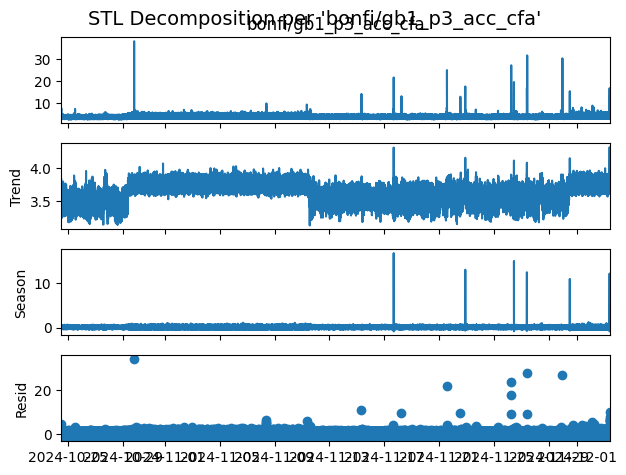

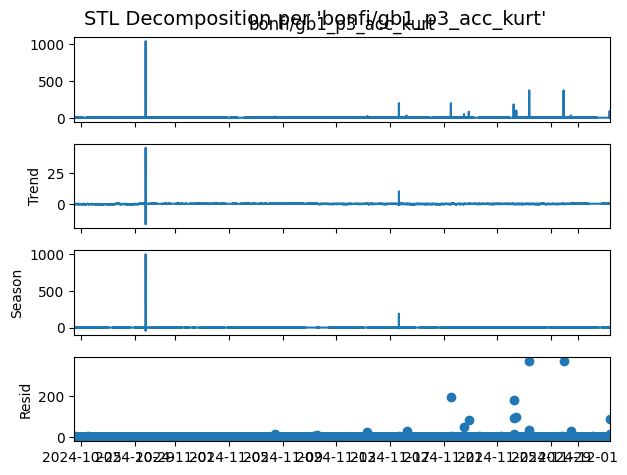

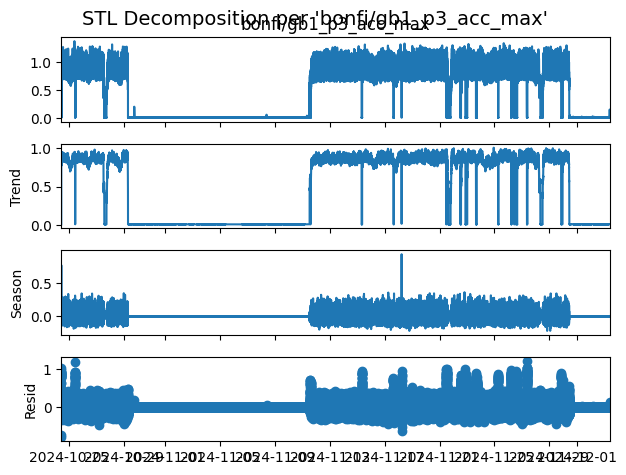

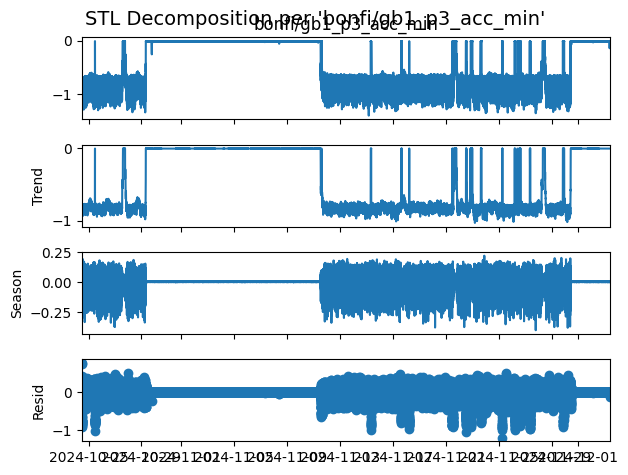

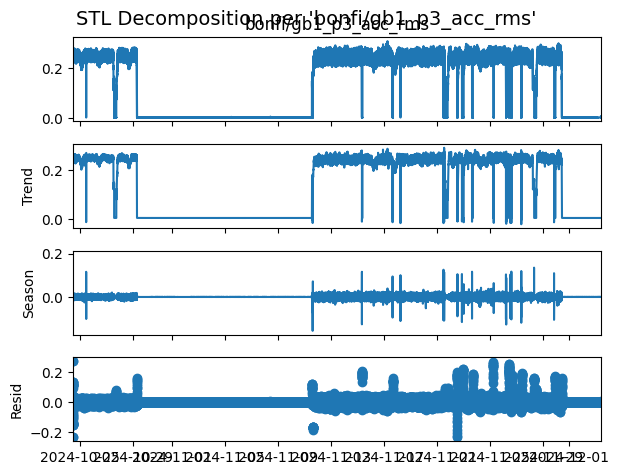

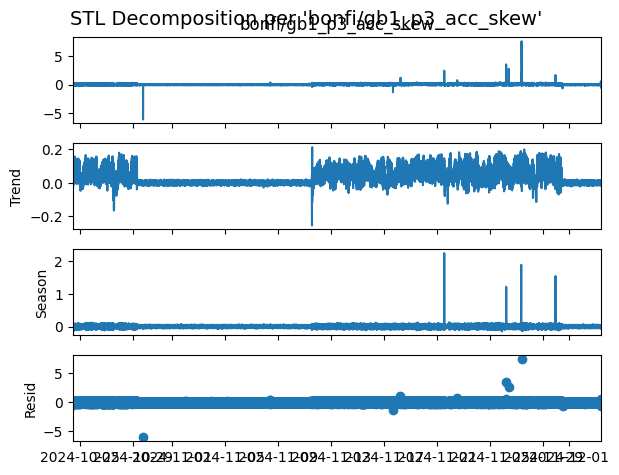

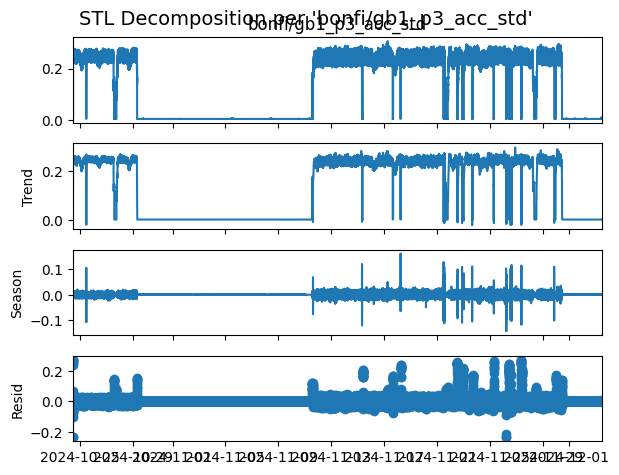

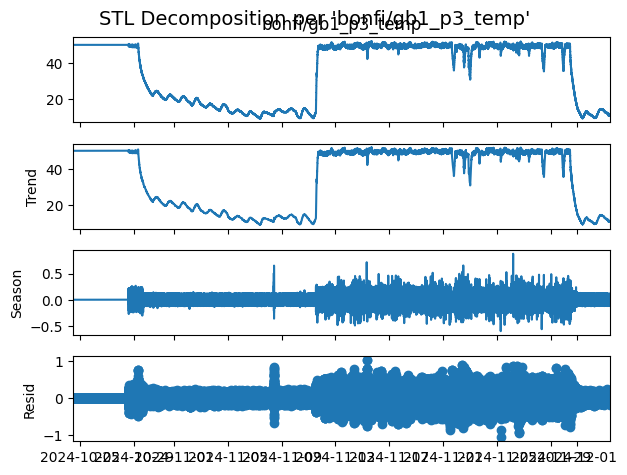

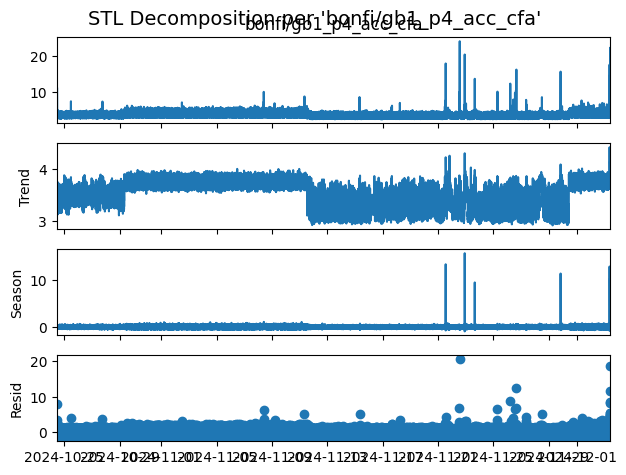

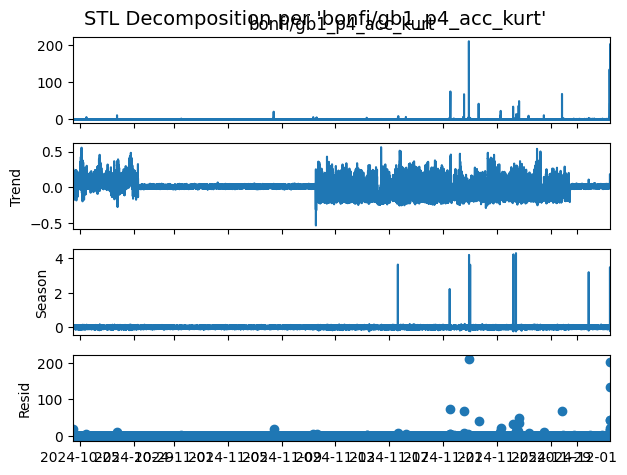

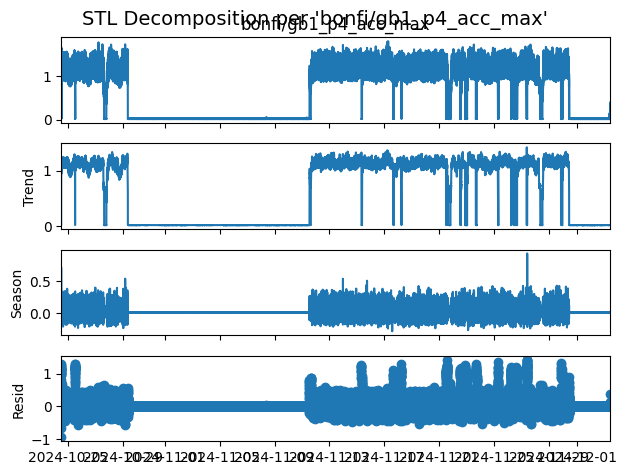

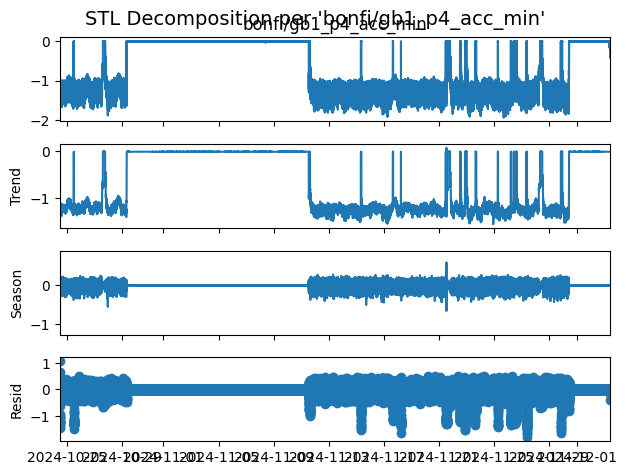

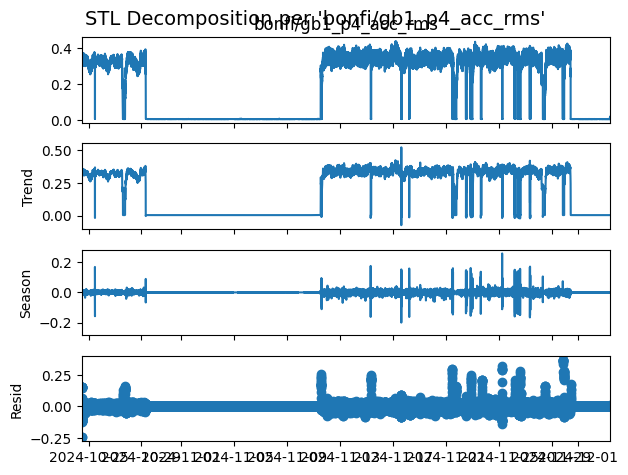

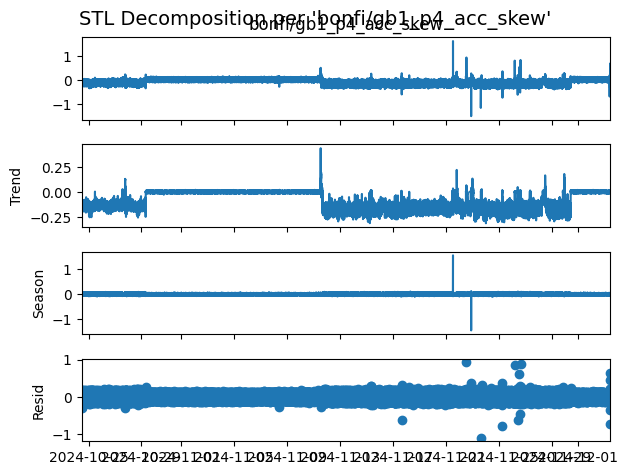

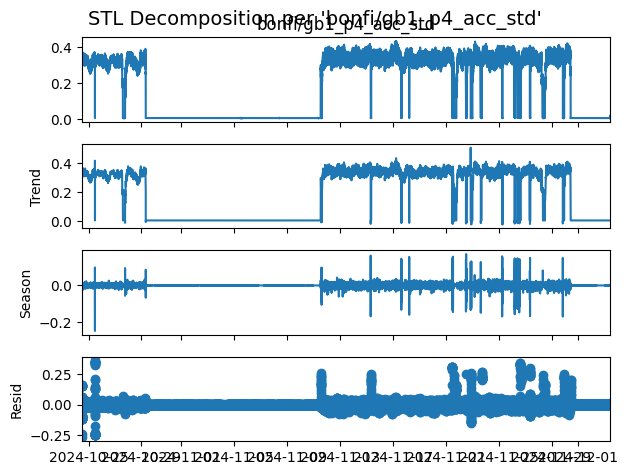

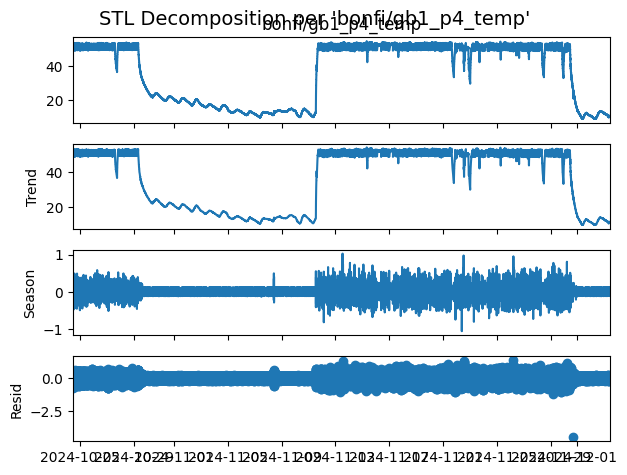

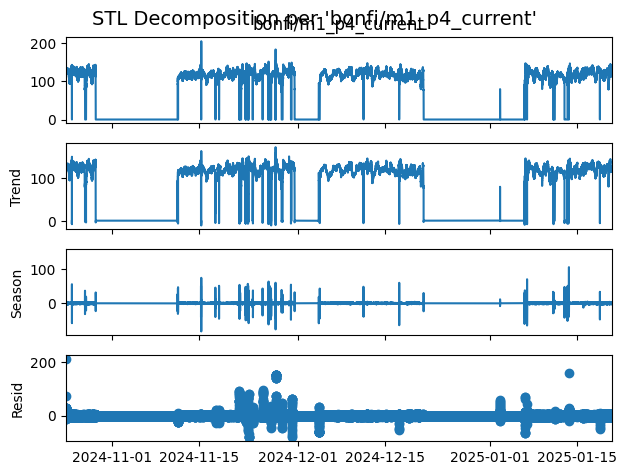

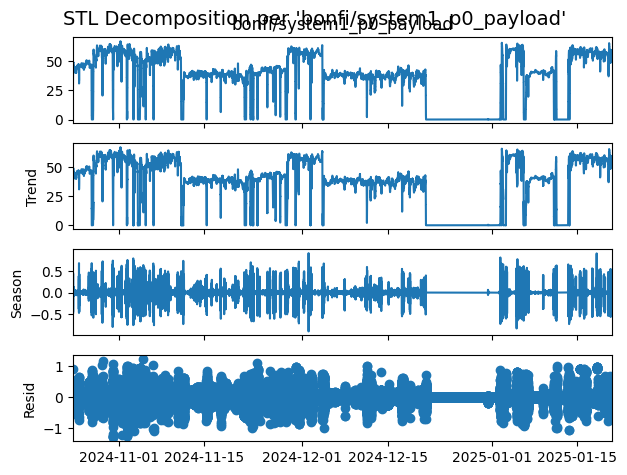

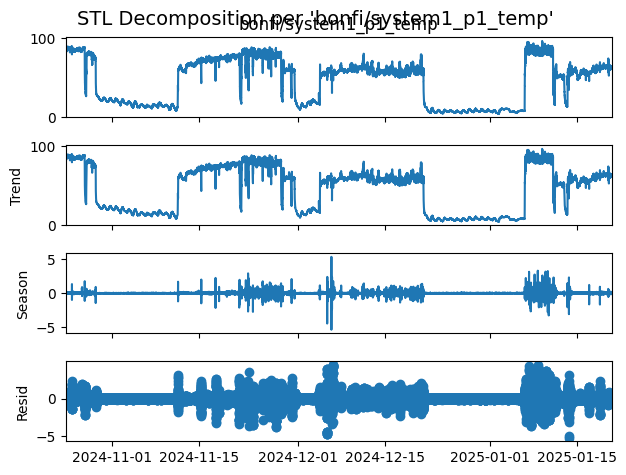

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import STL

# Esempio: supponiamo che df_ts sia il tuo DataFrame time series,
# con indice di tipo datetime e le colonne corrispondenti ai vari topic.

# Scegli un periodo in base ai tuoi dati
# (qui, come esempio, ipotizziamo 24 => ciclicità giornaliera con dati orari)
period = 24

# Itera su ciascuna colonna del df_ts
for col in df_ts.columns:
    # Se necessario, droppa i NaN (STL non gestisce i missing in automatico)
    serie = df_ts[col].dropna()

    # Se la colonna è vuota dopo dropna (o pochissimi punti), salta
    if len(serie) < period*2:
        print(f"Non abbastanza dati per {col}. Skipping.")
        continue

    # Esegui la decomposizione STL
    stl = STL(serie, period=period, robust=True)
    result = stl.fit()

    # Plot dei risultati: trend, season, resid
    fig = result.plot()

    # Titolo personalizzato
    fig.suptitle(f"STL Decomposition per '{col}'", fontsize=14)

    # Mostra il grafico (se stai in un ambiente tipo notebook va bene semplicemente plt.show())
    plt.show()


In [8]:
df_ts.head()

Topic,bonfi/gb1_p3_acc_cfa,bonfi/gb1_p3_acc_kurt,bonfi/gb1_p3_acc_max,bonfi/gb1_p3_acc_min,bonfi/gb1_p3_acc_rms,bonfi/gb1_p3_acc_skew,bonfi/gb1_p3_acc_std,bonfi/gb1_p3_temp,bonfi/gb1_p4_acc_cfa,bonfi/gb1_p4_acc_kurt,bonfi/gb1_p4_acc_max,bonfi/gb1_p4_acc_min,bonfi/gb1_p4_acc_rms,bonfi/gb1_p4_acc_skew,bonfi/gb1_p4_acc_std,bonfi/gb1_p4_temp,bonfi/m1_p4_current,bonfi/system1_p0_payload,bonfi/system1_p1_temp
Timestamp,,,,,,,,,,,,,,,,,,,
2024-10-24 11:18:21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.399808,0.008381,1.148129,-1.251302,0.338097,-0.083490,0.337891,52.5,NaN,NaN,NaN
2024-10-24 11:18:22,3.700691,-0.169714,NaN,NaN,0.230825,0.126804,NaN,49.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128.571442,39.433151,86.344536
2024-10-24 11:18:23,NaN,NaN,0.853956,-0.689925,NaN,NaN,0.230469,NaN,3.470473,-0.032152,1.188601,-1.299253,0.342058,-0.133289,0.341797,52.5,128.063004,39.433151,86.272575
2024-10-24 11:18:24,4.134402,0.006717,NaN,NaN,0.230911,0.176042,NaN,49.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128.063004,39.433151,86.272575
2024-10-24 11:18:25,NaN,NaN,0.954271,-0.756685,NaN,NaN,0.230469,NaN,3.356857,-0.081958,1.131054,-1.202478,0.335593,-0.111461,0.333984,52.5,128.063004,39.433151,86.272575


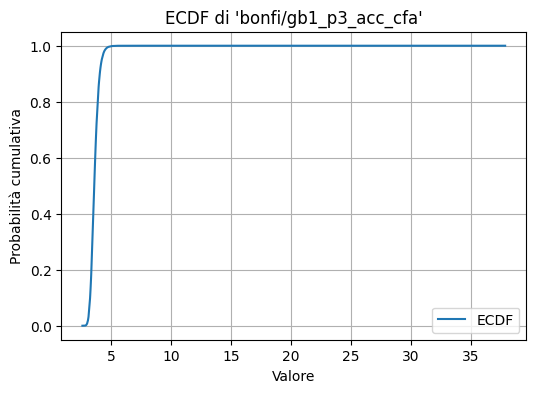

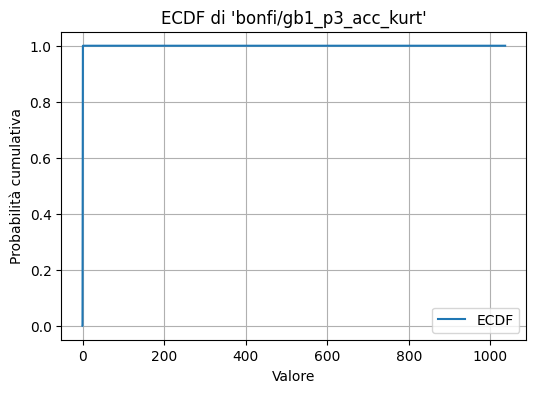

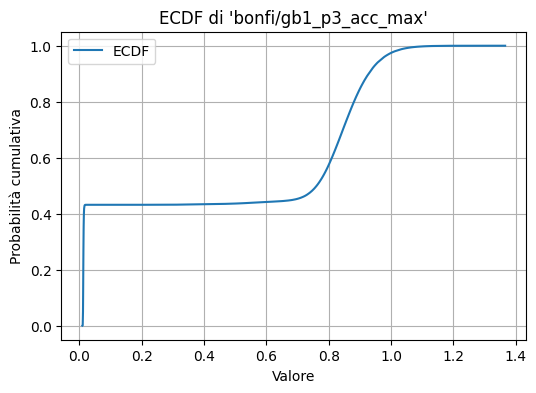

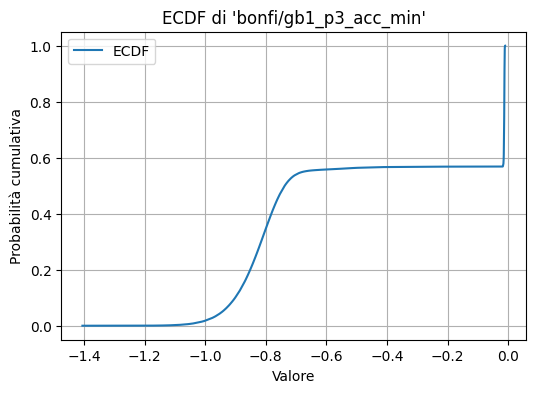

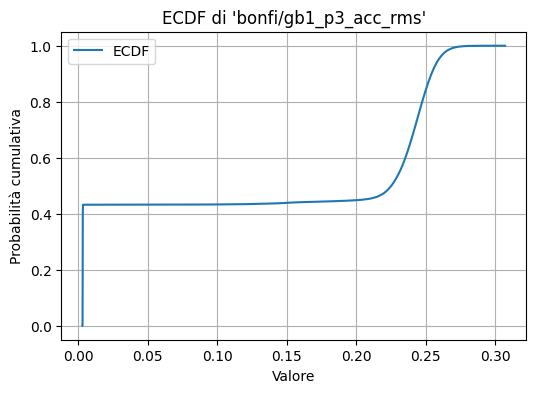

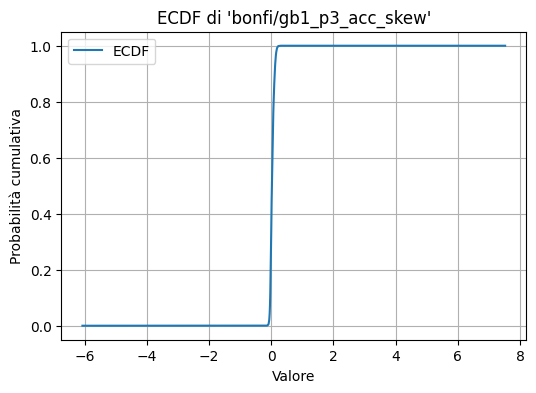

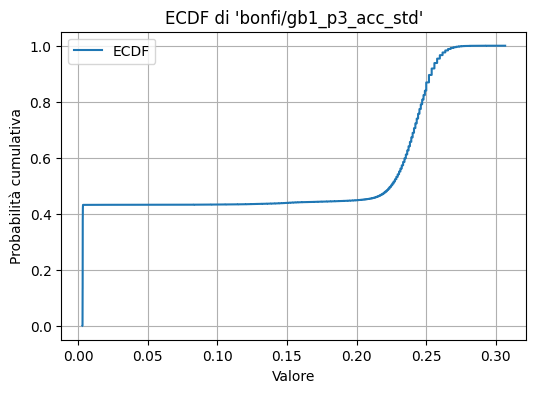

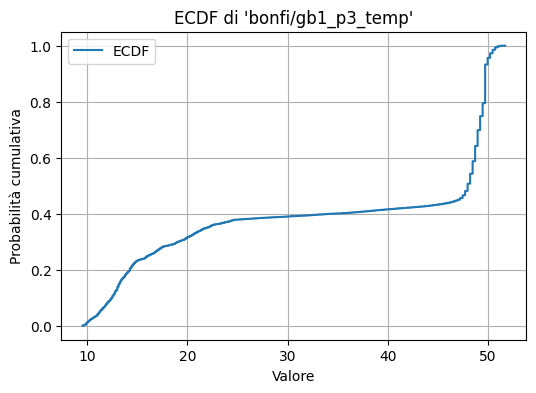

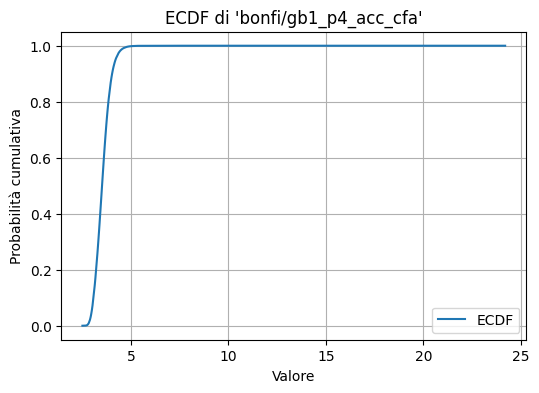

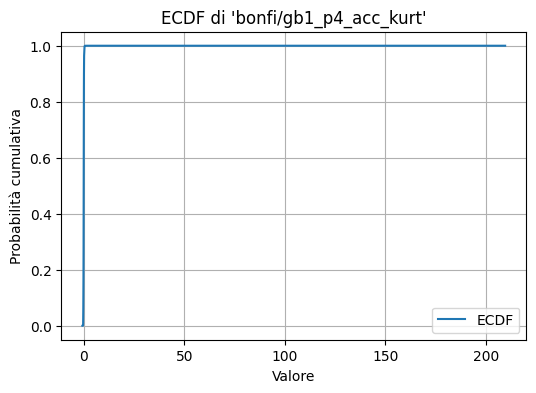

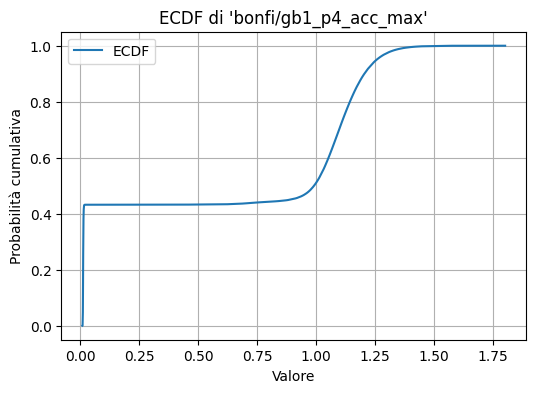

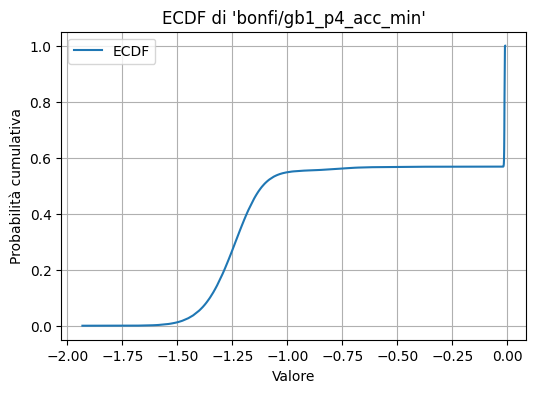

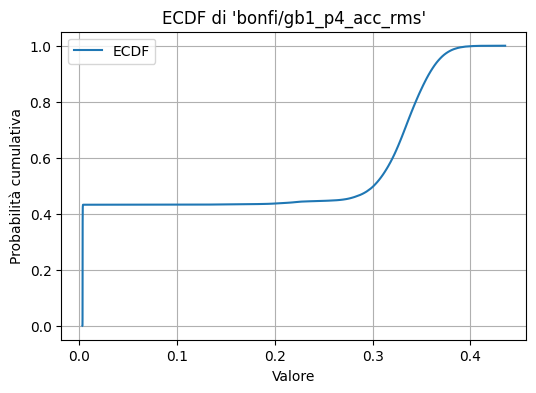

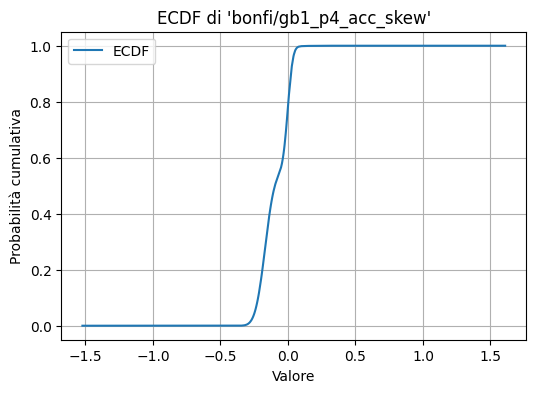

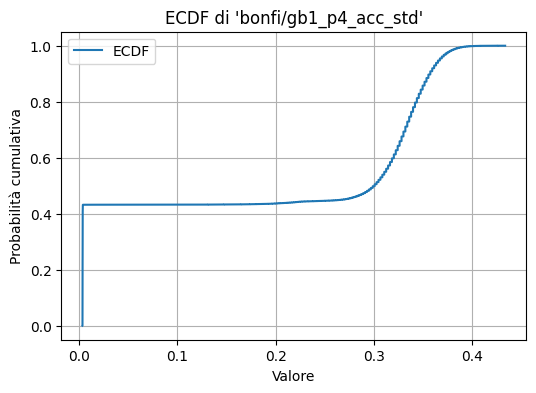

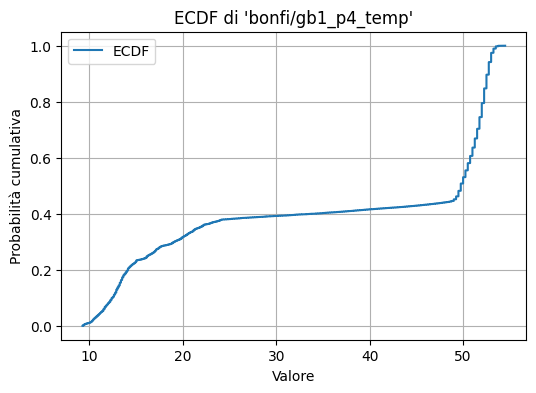

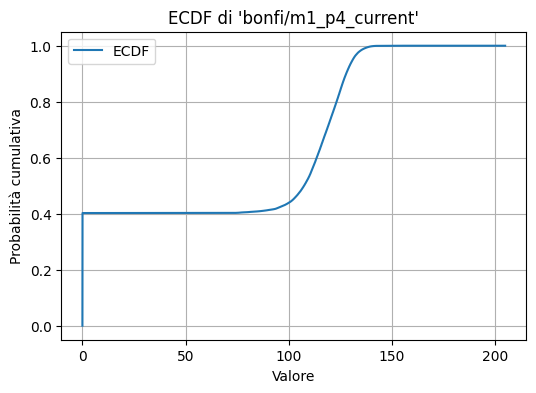

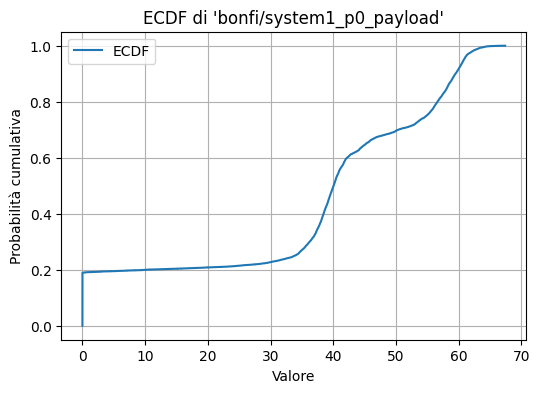

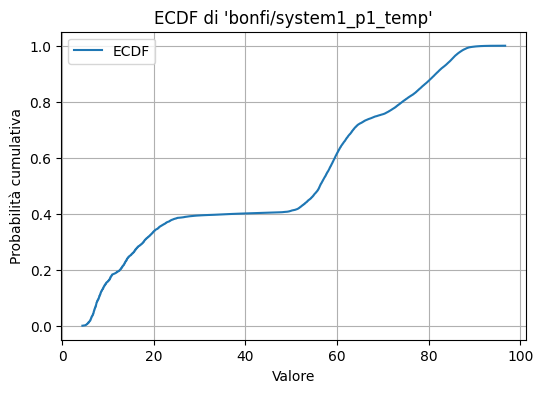

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# Supponendo che df_ts sia il tuo DataFrame con indice temporale e colonne = attributi
for col in df_ts.columns:
    # Prende i valori non NaN per la colonna
    values = df_ts[col].dropna()

    # Se la colonna è vuota dopo aver tolto i NaN, salta
    if values.empty:
        print(f"La colonna '{col}' è vuota o interamente NaN, salto il plot.")
        continue

    # Calcola la ECDF con statsmodels
    ecdf = ECDF(values)

    # Disegna il grafico
    plt.figure(figsize=(6, 4))
    plt.plot(ecdf.x, ecdf.y, label='ECDF')
    plt.title(f"ECDF di '{col}'")
    plt.xlabel("Valore")
    plt.ylabel("Probabilità cumulativa")
    plt.grid(True)
    plt.legend()
    plt.show()


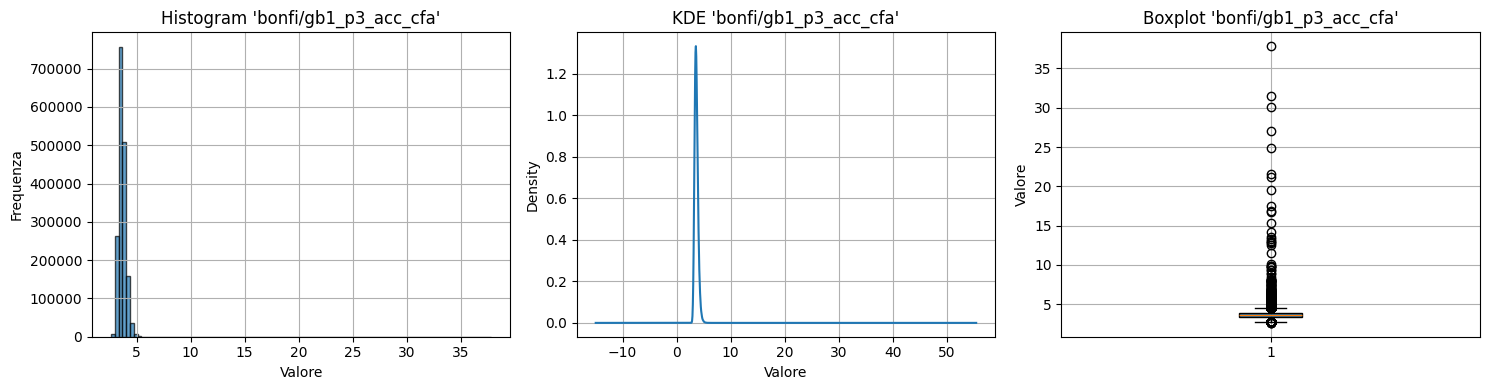

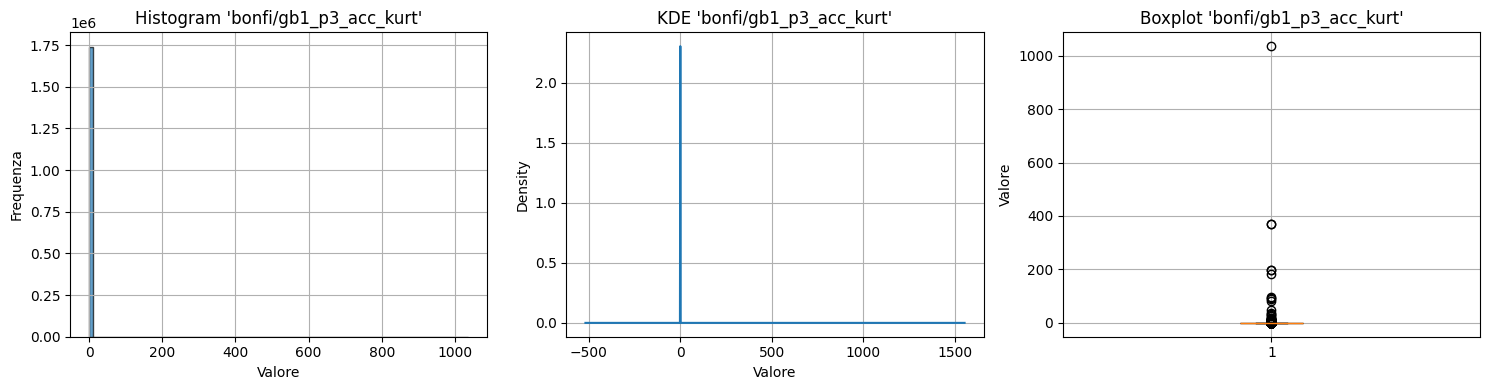

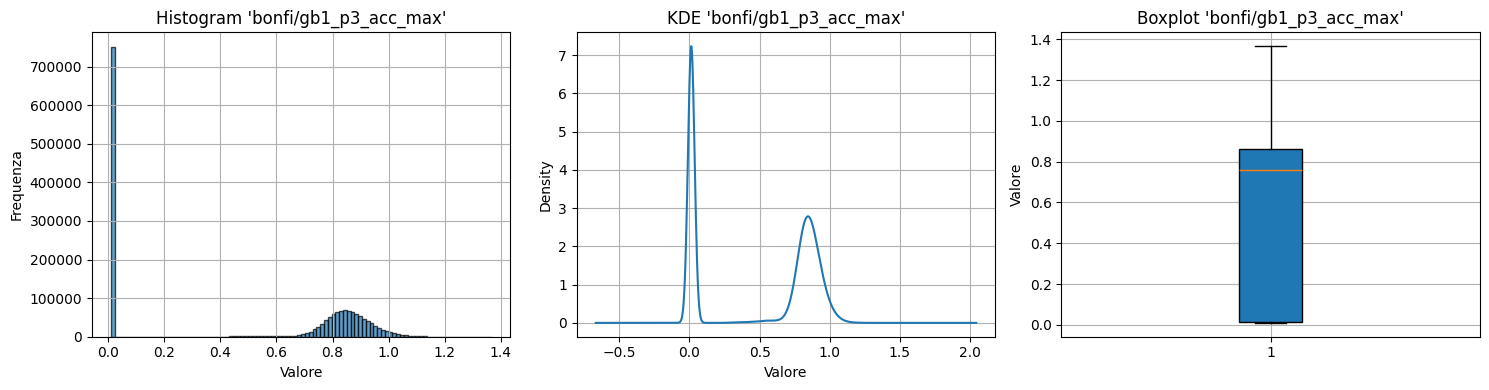

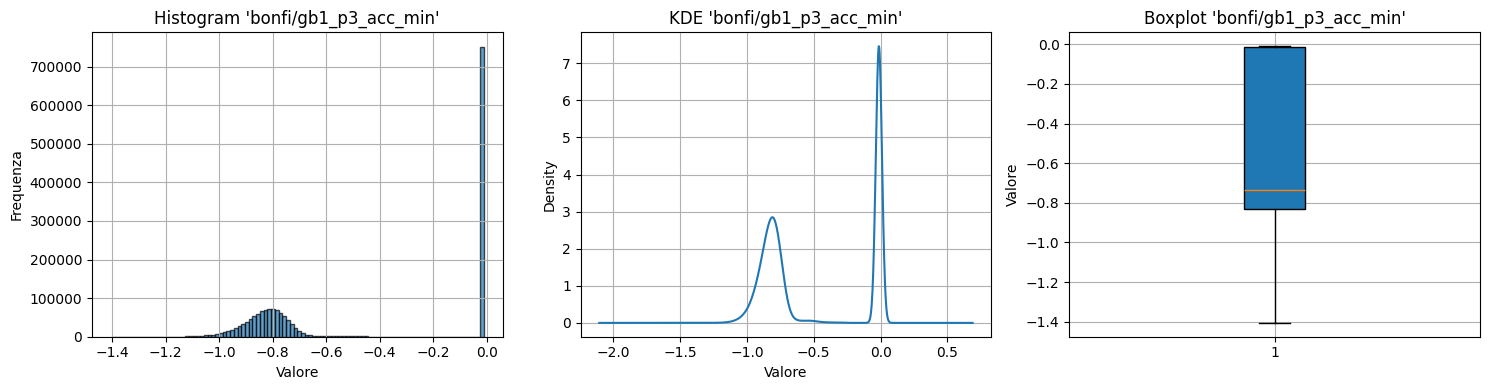

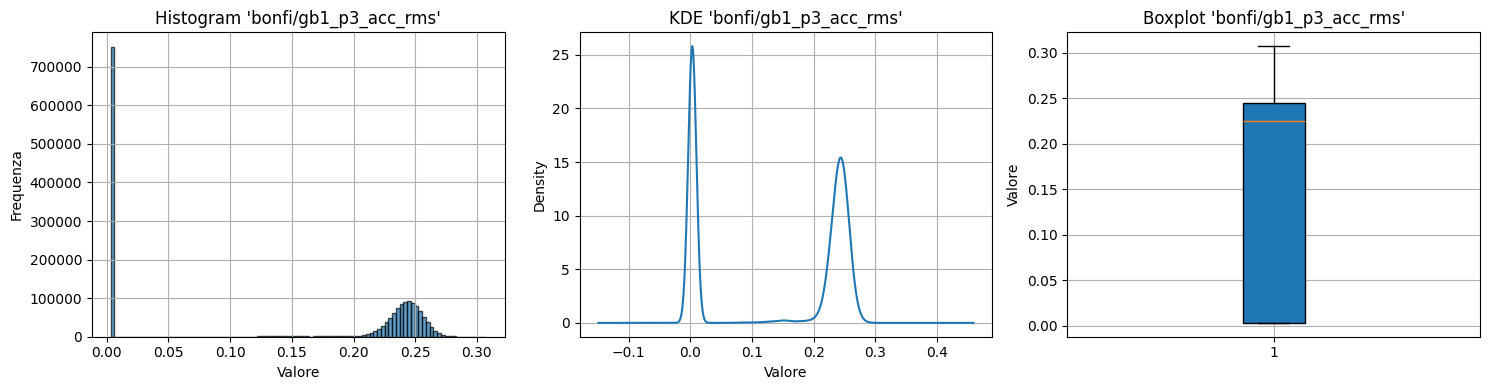

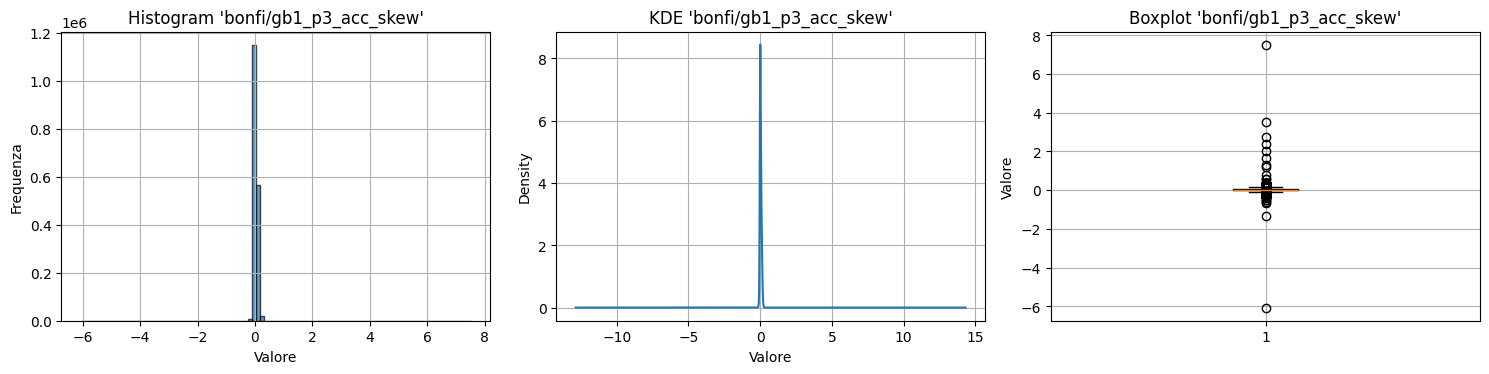

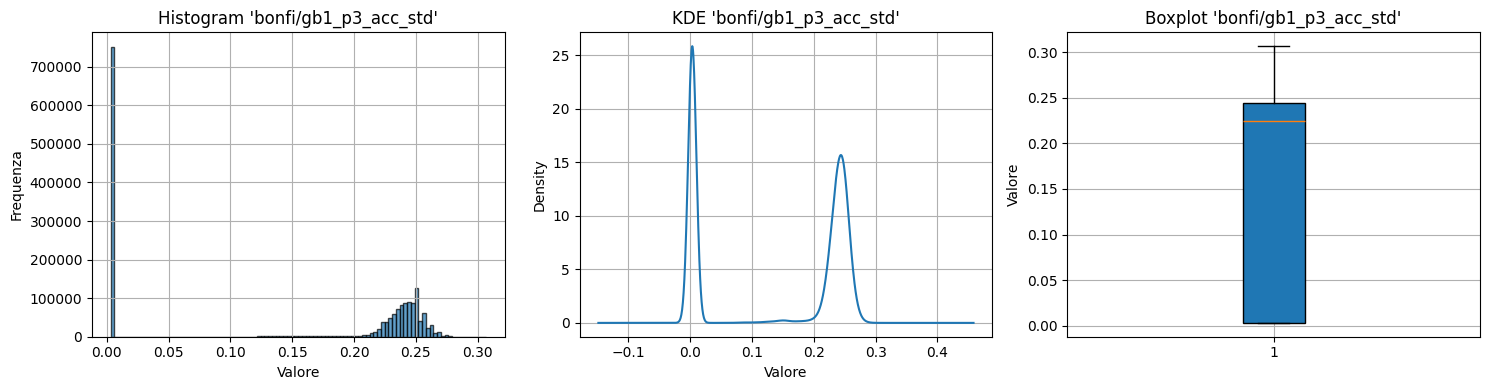

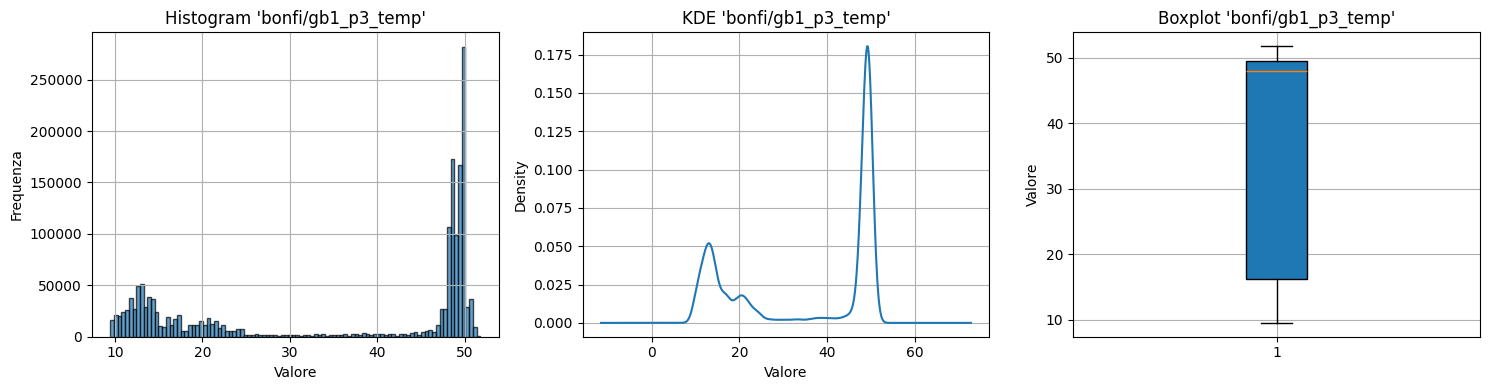

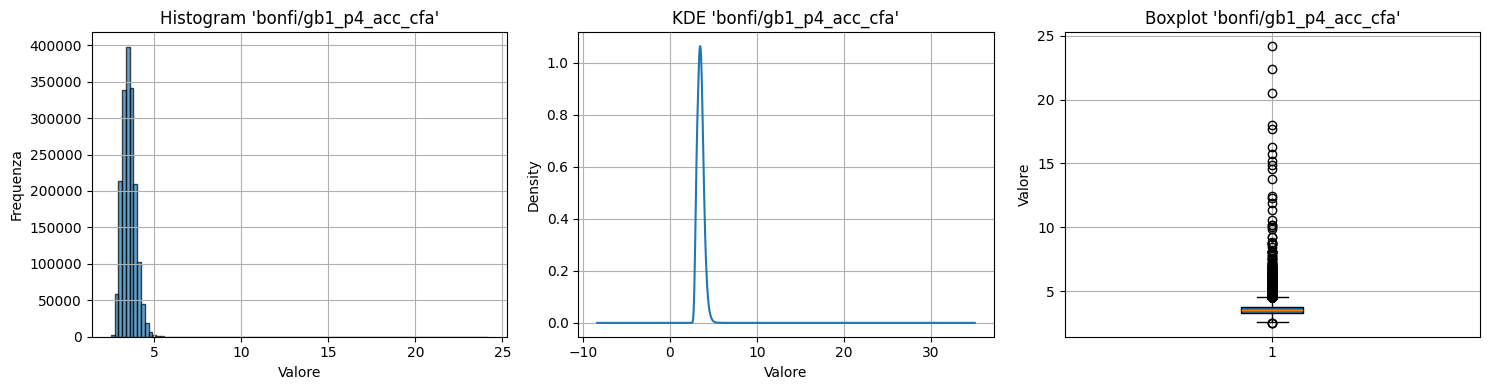

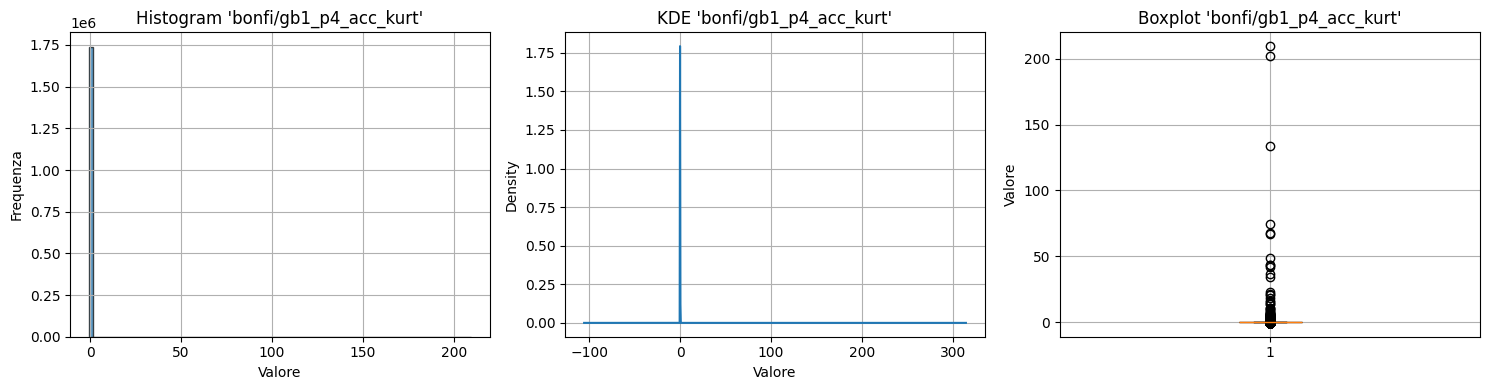

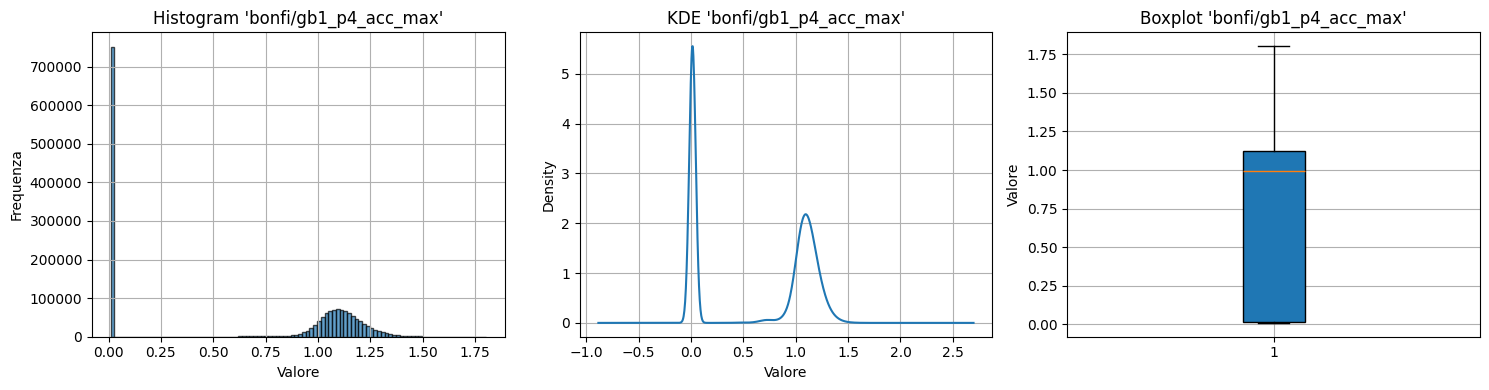

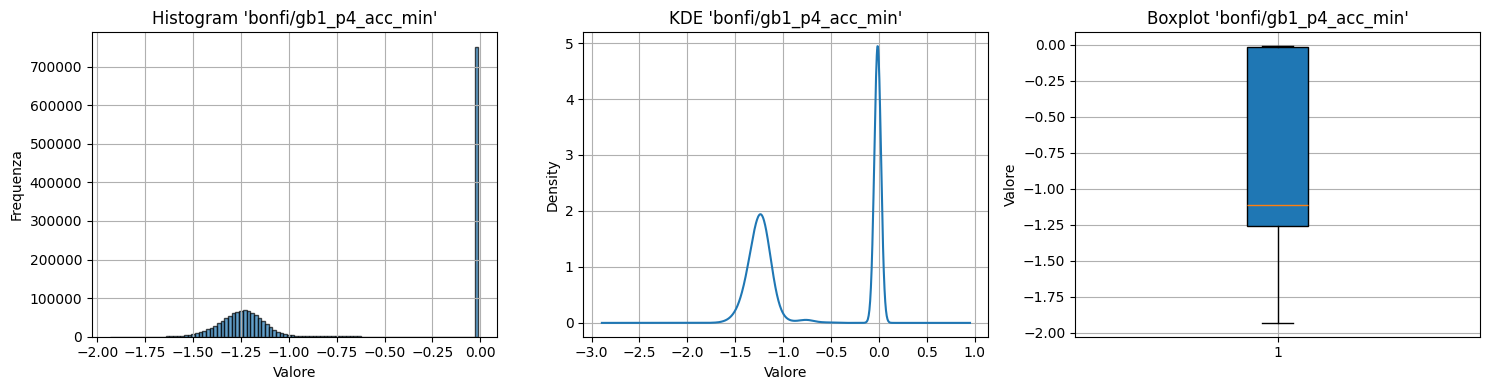

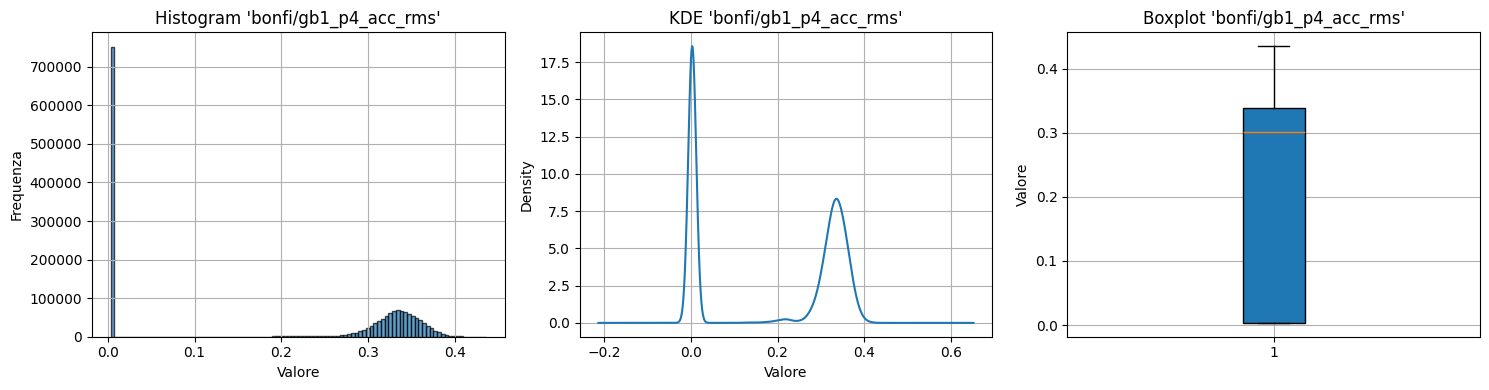

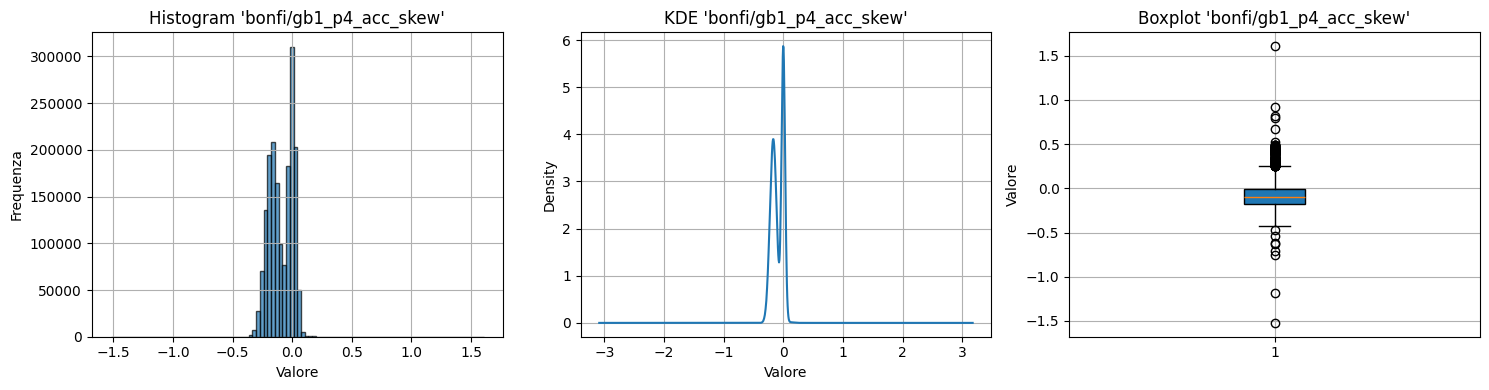

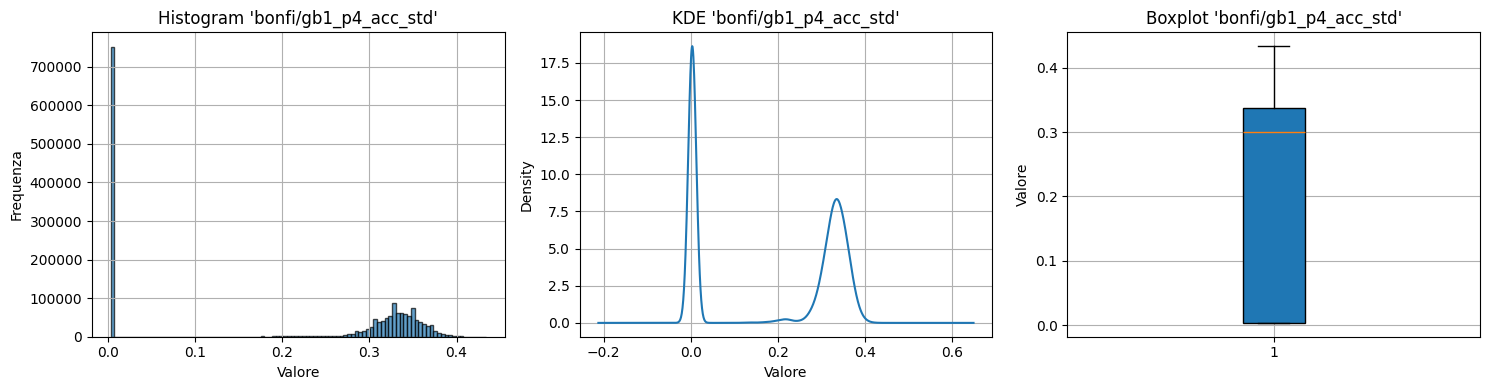

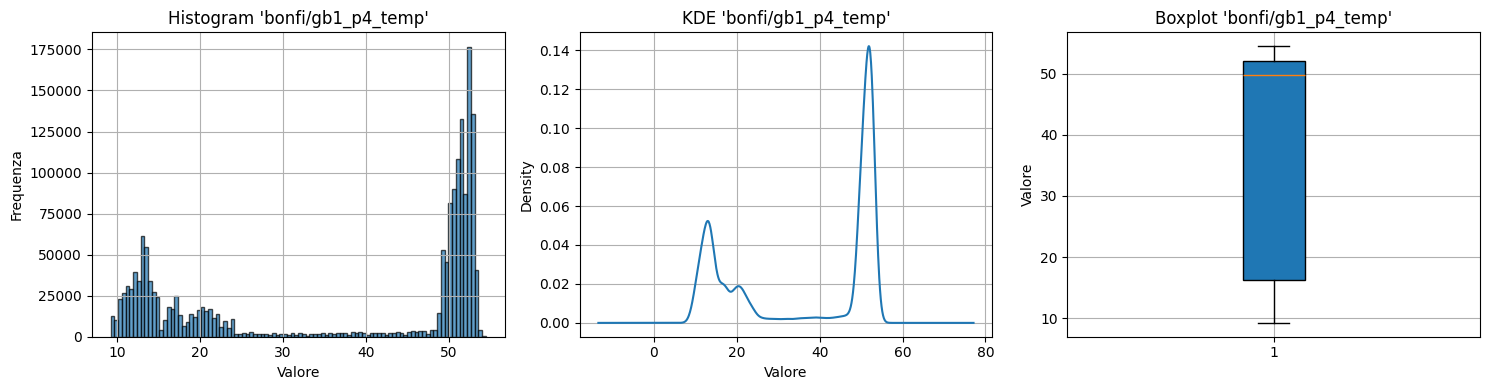

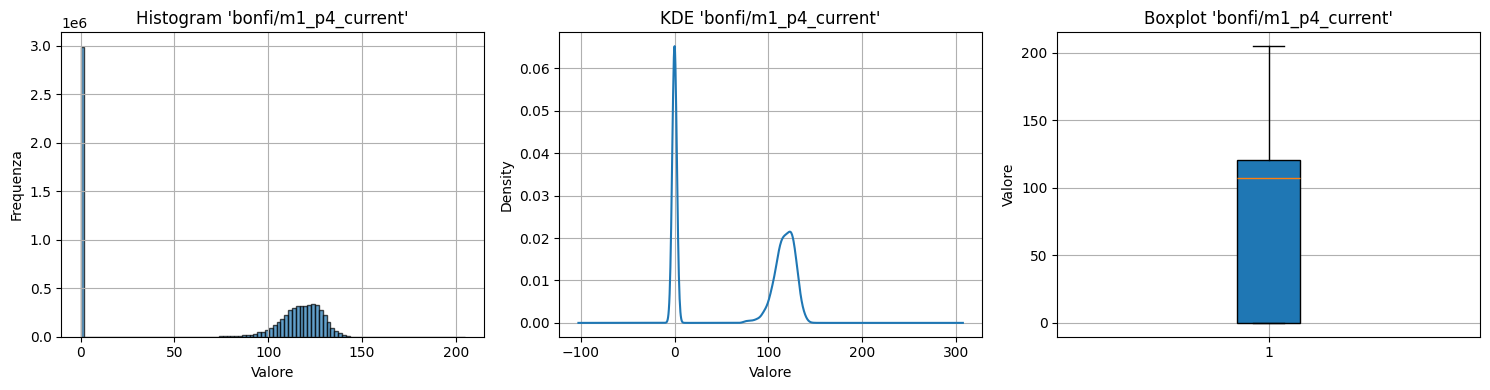

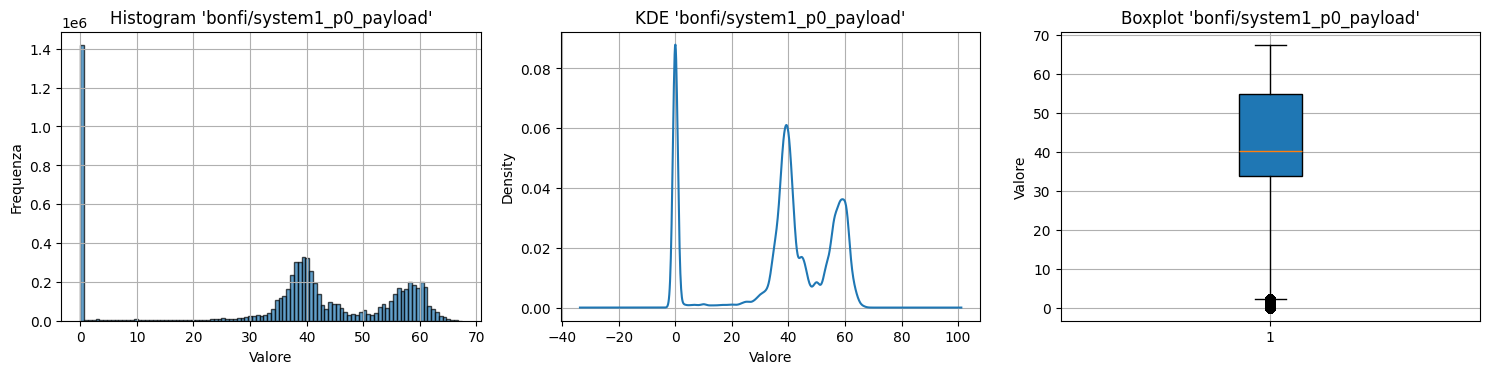

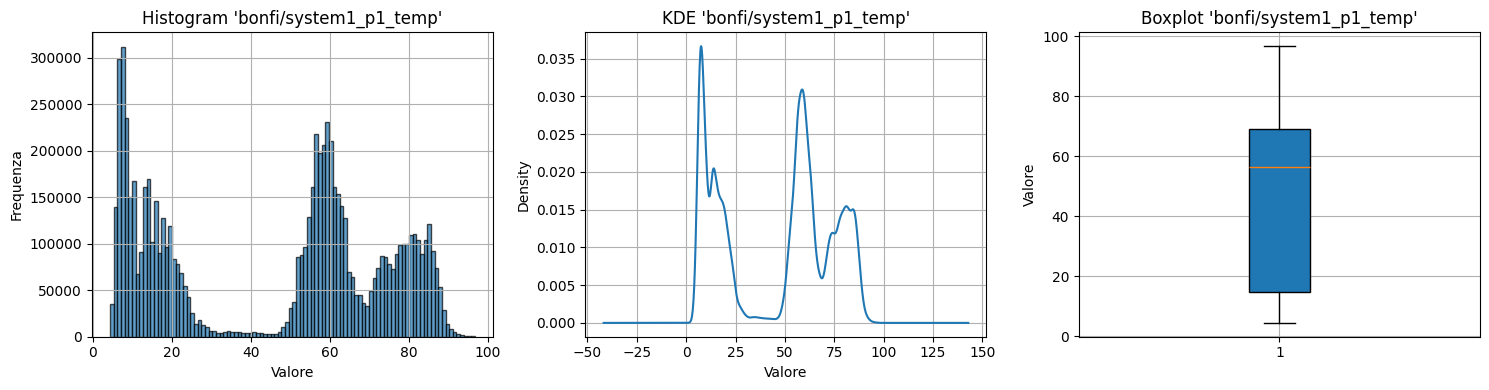

In [13]:
import matplotlib.pyplot as plt

# Itera sulle colonne (attributi) del DataFrame df_ts
for col in df_ts.columns:
    # Prendi i valori non NaN
    values = df_ts[col].dropna()

    # Se la colonna è vuota dopo il drop, salta
    if values.empty:
        print(f"La colonna '{col}' non ha valori validi, salto.")
        continue

    # Crea una figura con 3 subplot affiancati
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

    # --- 1) ISTOGRAMMA ---
    axes[0].hist(values, bins=100, alpha=0.7, edgecolor='black')
    axes[0].set_title(f"Histogram '{col}'")
    axes[0].set_xlabel("Valore")
    axes[0].set_ylabel("Frequenza")
    axes[0].grid(True)

    # --- 2) DENSITY PLOT (KDE) ---
    # Usando Pandas .plot(kind='kde'), oppure Seaborn se preferisci
    # Qui mostriamo un KDE con la funzione di Pandas
    values.plot(kind='kde', ax=axes[1])
    axes[1].set_title(f"KDE '{col}'")
    axes[1].set_xlabel("Valore")
    axes[1].grid(True)

    # --- 3) BOXPLOT ---
    axes[2].boxplot(values, vert=True, patch_artist=True)
    axes[2].set_title(f"Boxplot '{col}'")
    axes[2].set_ylabel("Valore")
    axes[2].grid(True)

    # Spazio tra i subplots
    plt.tight_layout()

    # Mostra la figura
    plt.show()
